# Value-recurrence prediction on Acrobot-v1

**What this experiment asks.** As an ordinary DQN agent learns, does the value
signal along its trajectories become describable by a single linear recurrence
of low order? And if so, is that recurrence any use for *prediction* rather than
merely for description?

**The setup, in full.**

* The agent is a **plain baseline DQN**. There is no Hankel-rank regularisation
  term anywhere in the loss. Nothing pushes the agent towards low-rank values,
  so whatever structure appears is a property of ordinary Q-learning and not
  something the objective manufactured.
* Every `analysis.ep_freq` episodes the policy is **frozen** and rolled greedily
  (argmax, no exploration noise) from a fixed set of probe seeds. The values
  recorded are `V(state) = max over actions of Q(state, action)` at each step.
  Nothing about the agent is mutated by the probe.
* At each such checkpoint one **global** linear recurrence is fitted per order
  in the config's `autoregressive_value_probe.orders` — global meaning all the fitted trajectories are pooled, so
  the coefficients describe the policy rather than any single rollout.

**Two independent splits**, because "it fits" and "it predicts" are different claims:

| split | fitted on | scored on | the question it answers |
|---|---|---|---|
| held-out trajectories | some trajectories | *other* trajectories from the same frozen policy | does one recurrence describe this policy in general? |
| prefix / suffix | first half of each trajectory | second half of the same trajectory | given how a trajectory starts, does the recurrence say how it ends? |

**Two prediction regimes**, because a model can fit well and still be useless:

* **one step ahead** — every prediction is made from the *true* previous values,
  so errors never accumulate. The optimistic number.
* **rolling forecast, one error per window τ** — the recurrence predicts τ
  steps from the true history, is re-anchored on the values that actually
  occurred, then predicts the next τ. Errors compound within a window, so
  sweeping τ shows how far ahead the recurrence stays useful — and where an
  over-parameterised order shows itself. τ = 1 is exactly one-step-ahead, and a
  τ longer than the trajectory never re-anchors at all (a fully free-running
  forecast).

Errors are reported both as plain **RMSE**, in the value signal's own units,
and as **1 − R²**, the fraction of the signal's variance the prediction leaves
unexplained: 0 is perfect, 1 is no better than predicting the signal's own
mean. The latter is what makes CartPole and Acrobot comparable at all —
their raw value scales differ by orders of magnitude.

Acrobot values are large and negative and rise sharply as the goal is approached, so the value signal has a pronounced end-of-episode transient that a low-order recurrence has to capture.

Everything below is also viewable interactively in the result viewer app:

```bash
python result_viewer_app/rank_viewer.py
```


## Setup

In [1]:
import pathlib
import sys

import matplotlib.pyplot as plt

REPOSITORY_ROOT = pathlib.Path.cwd().parents[2]
sys.path.insert(0, str(REPOSITORY_ROOT / "src"))
sys.path.insert(0, str(REPOSITORY_ROOT / "experiments" / "src"))

from analysis.visualisations import autoregressive_value_plots as value_plots

plt.rcParams["figure.dpi"] = 110
CONFIG_PATH = "configs/config_autoregressive_recurrence.yaml"


## Run the experiment

This trains the baseline DQN agent with the probe attached, writing every
artifact under `runs/<timestamp>/`. It takes a while; skip this cell and run the
next one instead to analyse a run that already exists.

In [2]:
from run_autoregressive_recurrence import run_experiment
run_directory, episode_rewards = run_experiment(CONFIG_PATH)
print(run_directory)


  0%|          | 0/500 [00:00<?, ?it/s]

episode 0 avg_rewarg: -500.0


  0%|          | 1/500 [00:03<26:40,  3.21s/it]

  1%|          | 5/500 [00:03<04:08,  1.99it/s]

**************** autoregressive value probe (50 trajectories, mean length 500) ****************
  order 2: held-out test 1 - R^2  one-step 0.1702 | by forecast window: tau=1 0.1702  tau=2 0.4221  tau=4 1.2206  tau=8 2.8384  tau=16 2.9343  tau=32 3.4334  tau=64 4.3107
  order 4: held-out test 1 - R^2  one-step 0.1538 | by forecast window: tau=1 0.1538  tau=2 0.3663  tau=4 0.9610  tau=8 1.8242  tau=16 1.7097  tau=32 1.8466  tau=64 2.1467


...

 99%|█████████▉| 496/500 [02:22<00:00,  7.98it/s]

100%|█████████▉| 498/500 [02:22<00:00,  8.60it/s]

100%|██████████| 500/500 [02:22<00:00,  9.43it/s]

100%|██████████| 500/500 [02:22<00:00,  3.50it/s]

run artifacts saved under /home/souparna/Low-Rank-RL-TL/experiments/dqn_acrobot_2_revised/runs/20260809-004451
/home/souparna/Low-Rank-RL-TL/experiments/dqn_acrobot_2_revised/runs/20260809-004451


## Load the most recent run

In [3]:
# Picks by modification time among runs that actually contain probe output,
# so hand-named runs from other experiments in this directory are never chosen.
run_directory = value_plots.find_latest_run_with_probe("cached/runs")
checkpoints = value_plots.available_rollout_episodes(run_directory)
# Read the orders from the run rather than hardcoding them: they come from
# autoregressive_value_probe.orders, so a run configured with [2, 4] has no
# order 3 or 8, and every cell below must follow whatever this run fitted.
ORDERS = value_plots.available_orders(run_directory)
FITTED_INTERCEPT = value_plots.fitted_with_intercept(run_directory)
print(f"run directory   : {run_directory}")
print(f"orders fitted   : {ORDERS}")
print(f"intercept fitted: {FITTED_INTERCEPT}")
print(f"checkpoints   : {len(checkpoints)}  "
      f"(episodes {checkpoints[0]} to {checkpoints[-1]})")


run directory   : runs/20260809-004451
orders fitted   : [2, 4]
intercept fitted: False
checkpoints   : 50  (episodes 0 to 490)


## Learning curve

Context for everything that follows: a change in predictability is only
interesting if we know what the agent was doing at the time. The vertical lines
mark the probe checkpoints.

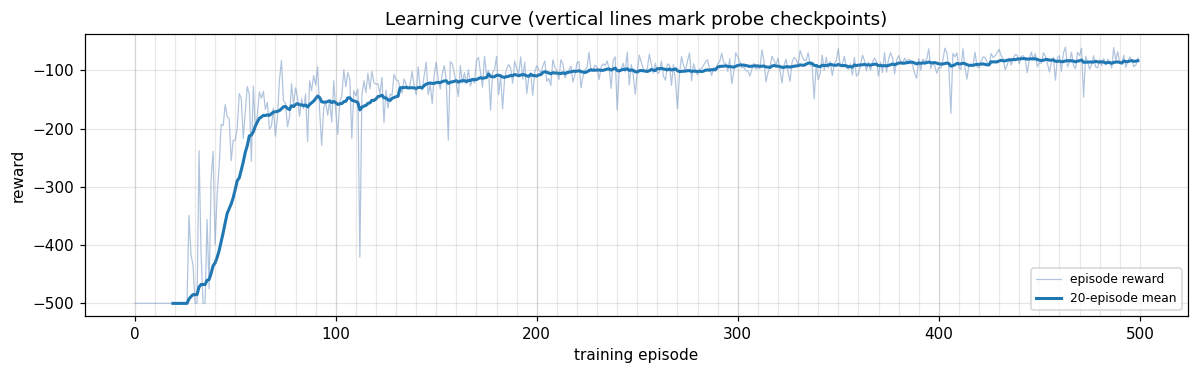

In [4]:
value_plots.plot_reward_with_checkpoints(run_directory);

## How predictable is the value signal, and does that change with training?

One column per recurrence order, training on the top row and test on the
bottom, log scale. Within each panel there is one line per forecast window τ:
the recurrence predicts τ steps from the true history, is re-anchored on the
values that actually occurred, then predicts the next τ.

The row that carries the claim is **test** — trajectories the fit never saw —
and the lines that carry it are the long windows: any fit looks decent at
τ = 1, but only a recurrence that genuinely describes the signal keeps its
error down as τ grows.

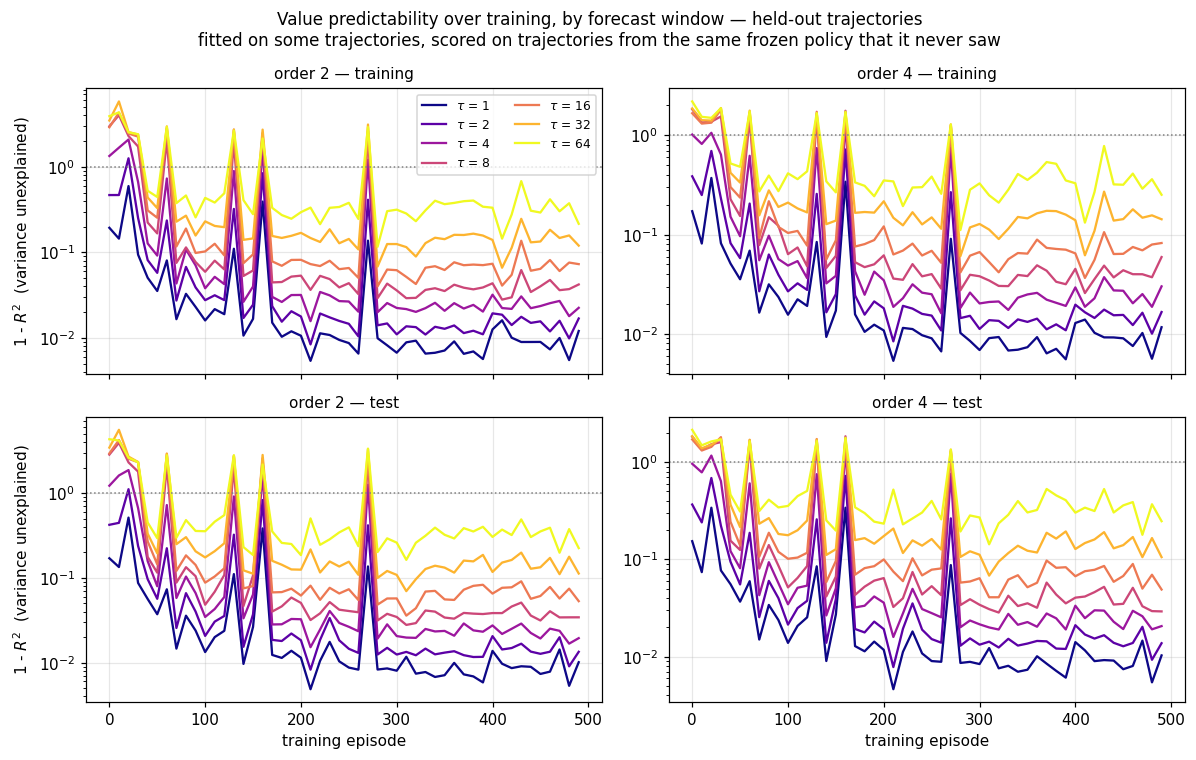

In [5]:
value_plots.plot_prediction_error_over_training(
    run_directory, split=value_plots.HELD_OUT_TRAJECTORY_SPLIT);

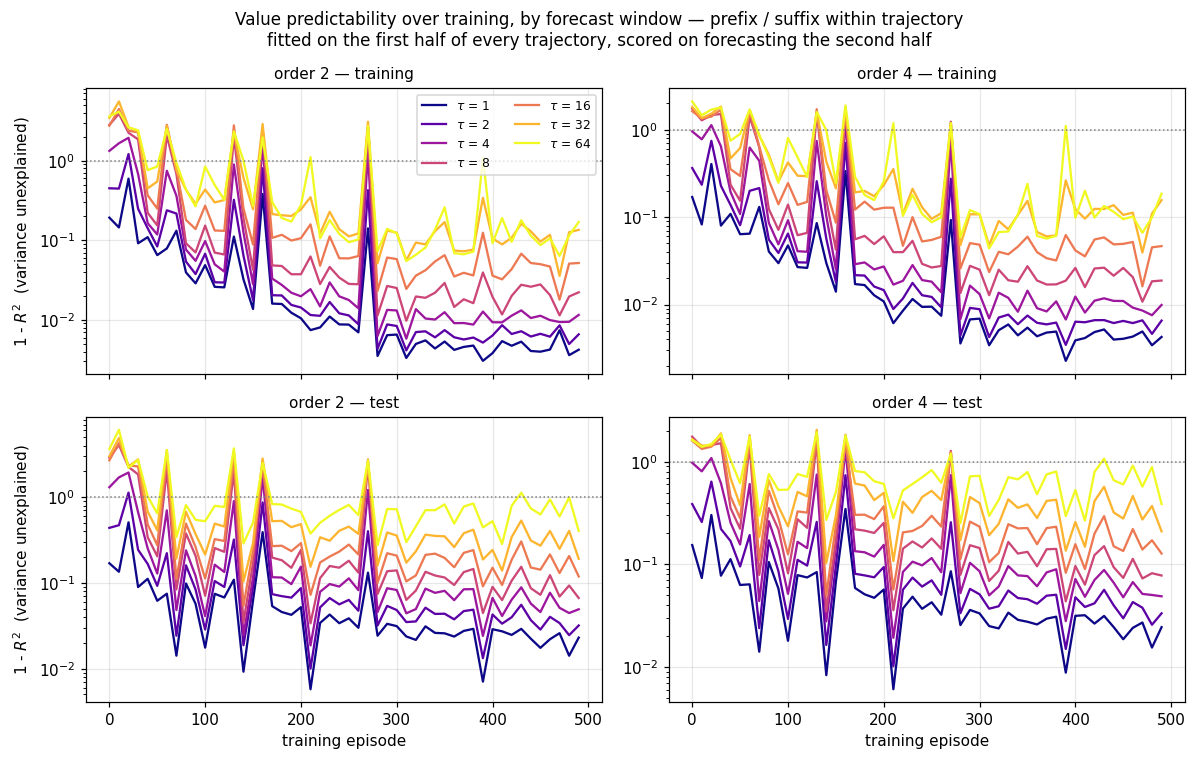

In [6]:
value_plots.plot_prediction_error_over_training(
    run_directory, split=value_plots.PREFIX_SUFFIX_SPLIT);

### Where it ended up

Held-out test error at the final checkpoint, one row per recurrence order and
one column per forecast window — first as 1 − R², then the same slice as plain
RMSE in the value signal's own units.

In [7]:
print("1 - R^2, fraction of variance unexplained "
      "(held-out test, final checkpoint):")
display(value_plots.summarise_final_checkpoint(run_directory).round(4))
print("RMSE in the value signal's own units (same slice):")
value_plots.summarise_final_checkpoint(run_directory, metric="rmse").round(6)

1 - R^2, fraction of variance unexplained (held-out test, final checkpoint):


,tau=1,tau=2,tau=4,tau=8,tau=16,tau=32,tau=64
order,,,,,,,
2,0.0101,0.0134,0.0194,0.0342,0.0531,0.1125,0.2242
4,0.0103,0.0137,0.0206,0.0292,0.0490,0.1055,0.2468


RMSE in the value signal's own units (same slice):


,tau=1,tau=2,tau=4,tau=8,tau=16,tau=32,tau=64
order,,,,,,,
2,1.705983,1.964415,2.364804,3.138074,3.908213,5.689732,8.031989
4,1.723169,1.990417,2.437124,2.900259,3.757542,5.513567,8.434762


## How far ahead can the recurrence see?

The curves above track each forecast window across training; this figure fixes
a checkpoint and sweeps the window instead. At horizon τ the recurrence
predicts τ steps from the true history, is then re-anchored on the values that
actually occurred, and predicts the next τ — forecast a little way, observe,
forecast again.

The endpoints anchor the scale: **τ = 1** is the one-step-ahead fit, and a
**τ longer than the trajectory** never re-anchors at all, which makes it a
fully free-running forecast.

Reading the curve: one that **rises then flattens** has *saturated* — the
recurrence has decayed to predicting the signal's mean, so the error plateaus at
roughly the signal's own scale rather than growing without bound. One that
**keeps climbing steeply** is an unstable fit.

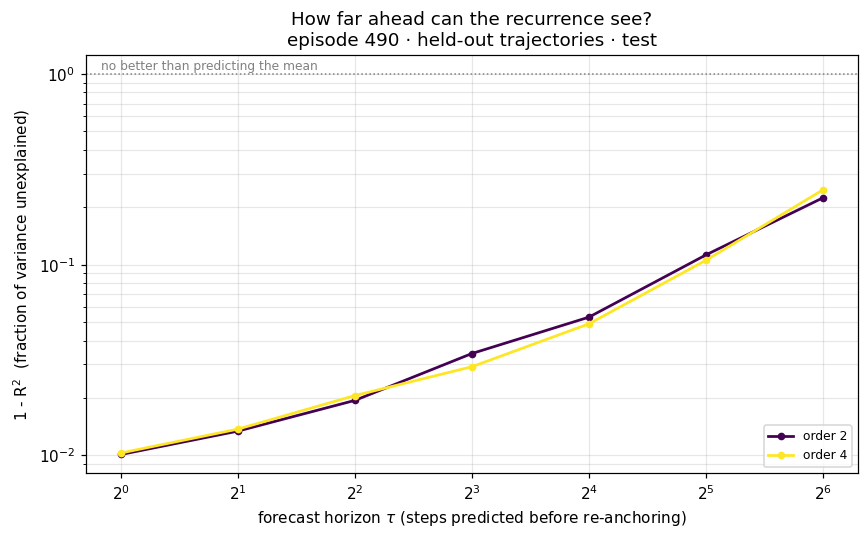

In [8]:
value_plots.plot_error_versus_forecast_horizon(run_directory);

The same sweep on the **training** subset — the distance from here to the
held-out test table above is how much of the fit is memorisation rather than
structure.

In [9]:
value_plots.summarise_horizon_sweep(run_directory,
                                    subset="training").round(4)

,tau=1,tau=2,tau=4,tau=8,tau=16,tau=32,tau=64
order,,,,,,,
2,0.0121,0.0169,0.0225,0.0422,0.0730,0.1201,0.216
4,0.0117,0.0166,0.0301,0.0594,0.0823,0.1427,0.252


### Does the signal become predictable *further ahead* as the agent learns?

One line per horizon, across training. If the agent's value signal is genuinely
becoming more structured, the long-horizon lines should fall too — not just the
τ = 1 line.

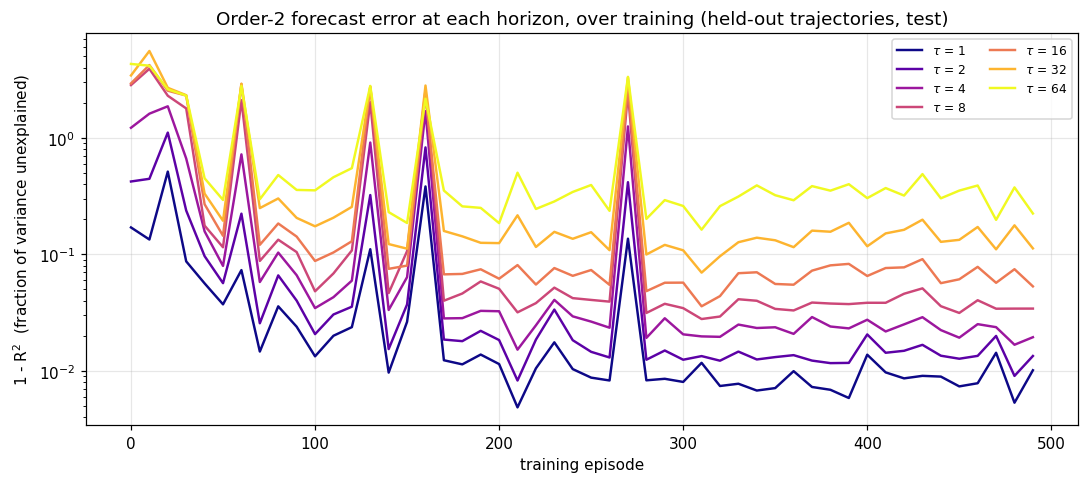

In [10]:
value_plots.plot_horizon_error_over_training(run_directory, order=ORDERS[0]);

## How do the coefficients themselves evolve?

One figure per recurrence order, one line per lag. Lag 1 is the weight on the
immediately preceding value.

The dashed line is the **sum of the lag weights**, and it is worth watching
separately from the individual coefficients: a sum near 1 is the persistence
(unit-root) regime, where the recurrence is mostly saying "the value stays where
it is". The individual weights can wander a great deal while that sum stays
pinned — which is a much more stable statement about the value signal than any
single coefficient is.

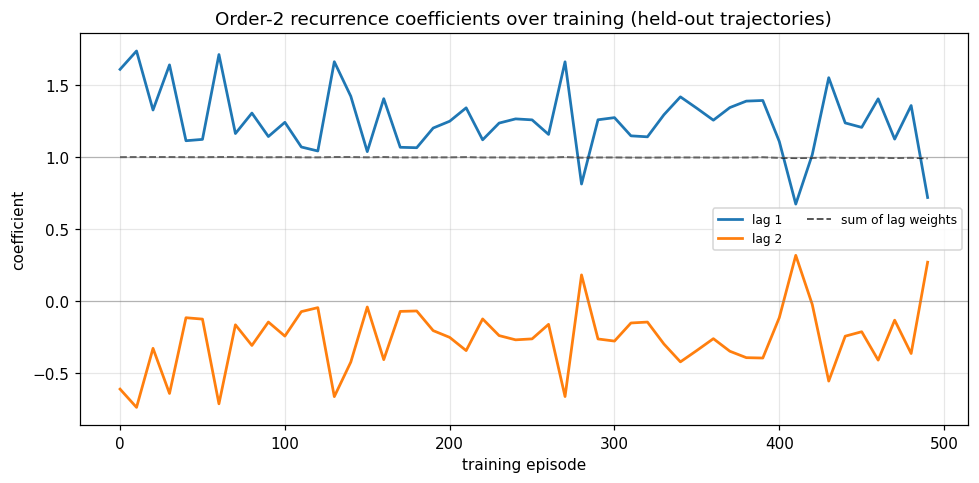

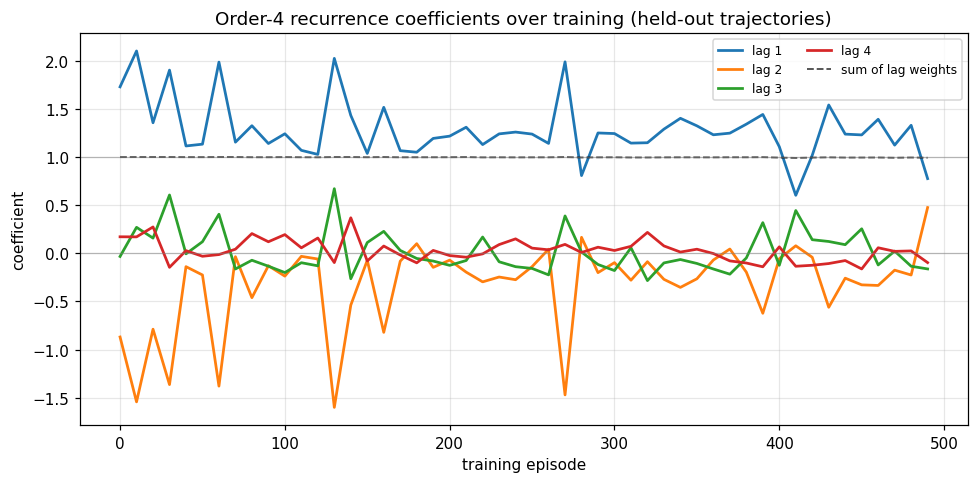

In [11]:
for order in ORDERS:
    value_plots.plot_coefficient_evolution(
        run_directory, order, include_intercept=FITTED_INTERCEPT);

### The same coefficients, from the prefix/suffix fit

A consistency check: coefficients fitted on first halves only should tell the
same story as coefficients fitted on whole trajectories, if the recurrence is a
property of the policy rather than an artefact of which segment was fitted.

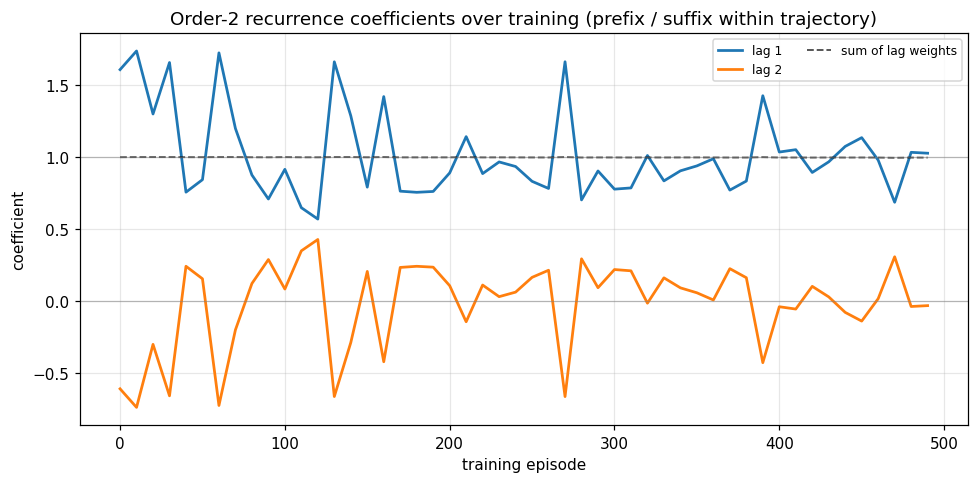

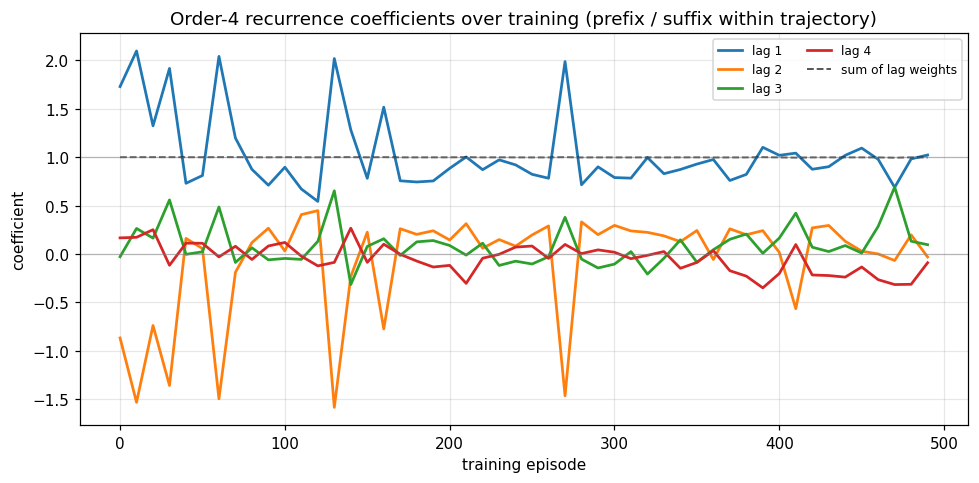

In [12]:
for order in ORDERS:
    value_plots.plot_coefficient_evolution(
        run_directory, order, split=value_plots.PREFIX_SUFFIX_SPLIT,
        include_intercept=FITTED_INTERCEPT);

## Example value rollouts: actual vs predicted

Single trajectories, with the true value in black, the one-step-ahead
prediction in blue, and one dashed rolling-forecast line per window τ (dark to
light with increasing τ). Top row is the **training** set, bottom row the
**test** set, so the same order can be compared across the two directly.

Each dashed line re-anchors on the true values every τ steps, so the gap it
opens before the next re-anchoring is exactly how fast the recurrence loses the
signal once it stops being told the truth. Pass `forecast_horizon=8` to
`plot_example_rollouts` to look at one window on its own.

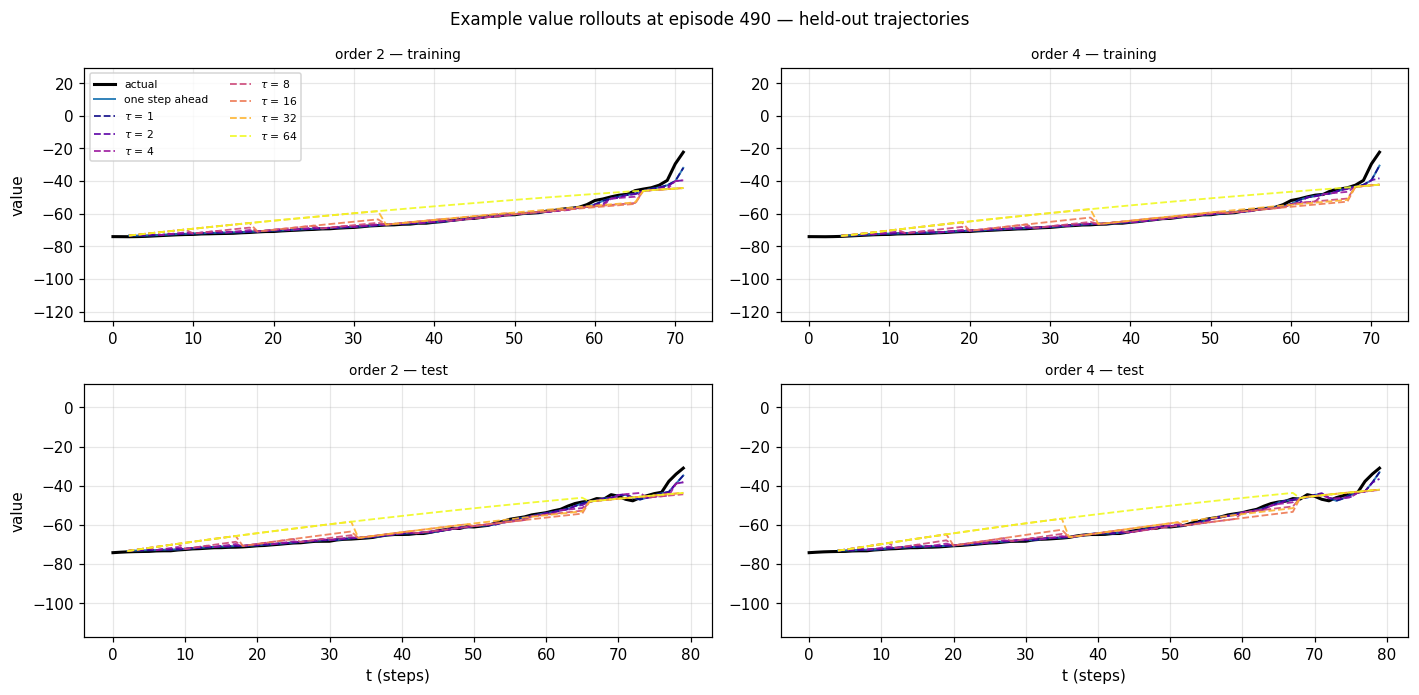

In [13]:
value_plots.plot_example_rollouts(run_directory);

### Earlier in training

The same plot at an early checkpoint, for comparison with the final one above.

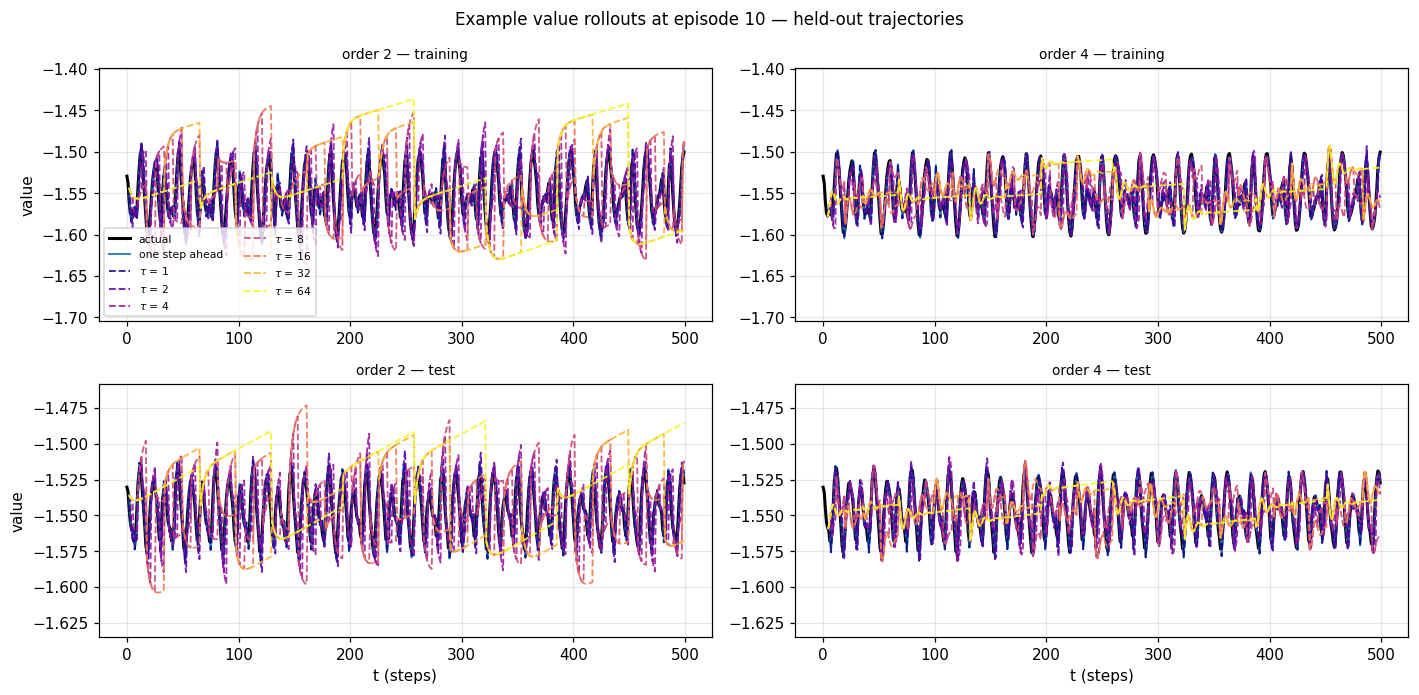

In [14]:
value_plots.plot_example_rollouts(run_directory, episode=checkpoints[1]);

### Forecasting the unseen second half

The prefix/suffix split, where the recurrence saw only the first half of these
very trajectories and has to forecast the rest.

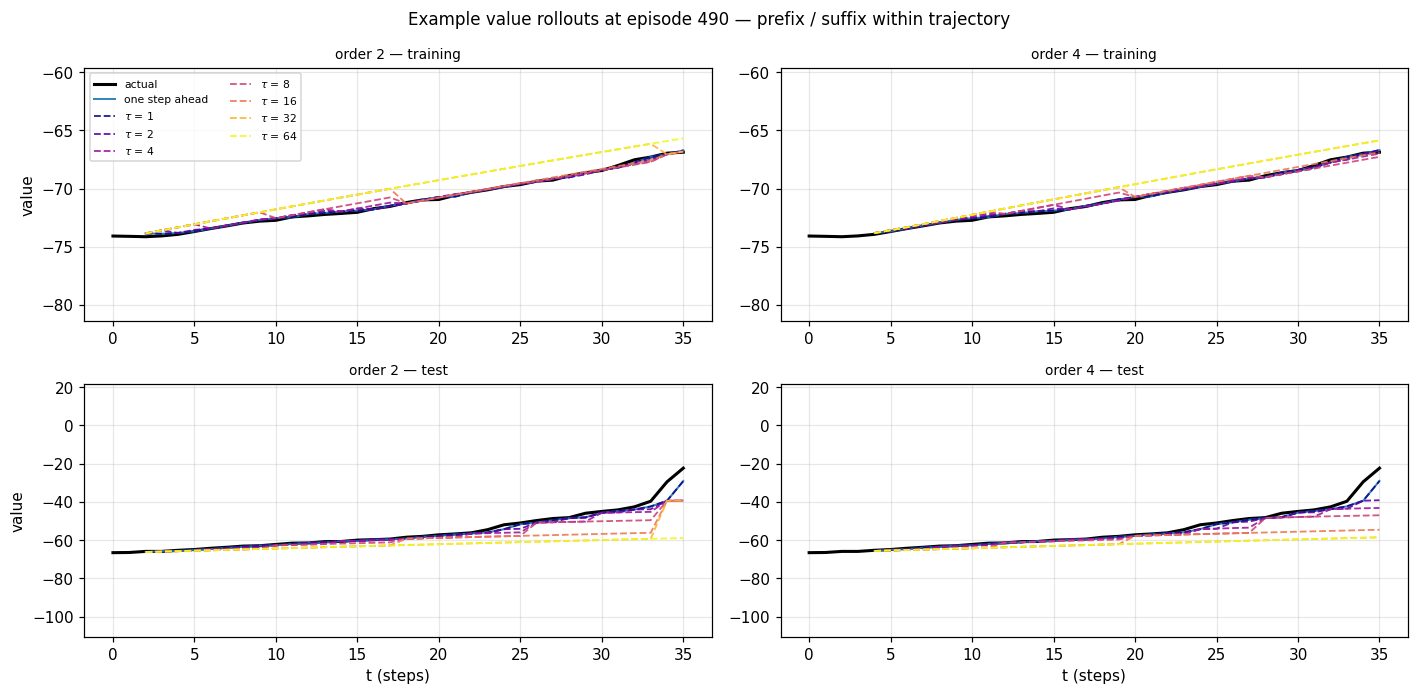

In [15]:
value_plots.plot_example_rollouts(
    run_directory, split=value_plots.PREFIX_SUFFIX_SPLIT);

## Raw artifacts

Everything plotted above is on disk and can be re-analysed without retraining:

| file | contents |
|---|---|
| `autoregressive_value_metrics.csv` | one row per (episode, order, split, subset) with the one-step-ahead RMSE and 1 − R² |
| `autoregressive_value_horizon_metrics.csv` | one row per (episode, order, split, subset, forecast window) with the RMSE and 1 − R² at that window |
| `autoregressive_value_coefficients.csv` | one row per (episode, order, split, lag); lag 0 is the intercept |
| `autoregressive_rollouts/epNNNNNN.npz` | actual, one-step-ahead, and per-window rolling-forecast arrays for the example trajectories |
| `rewards.csv`, `checkpoints/` | the ordinary training artifacts |


In [16]:
import pandas as pd
pd.read_csv(run_directory / "autoregressive_value_metrics.csv").tail(8)

,episode,order,split,subset,rmse_one_step_ahead,one_minus_r_squared_one_step_ahead,n_sequences_scored,n_trajectories_collected,mean_trajectory_length
392,490,2,held_out_trajectory_split,training,1.966145,0.012081,25,50,88.62
393,490,2,held_out_trajectory_split,test,1.705983,0.010117,25,50,88.62
394,490,2,prefix_suffix_split,training,0.524619,0.004214,50,50,88.62
395,490,2,prefix_suffix_split,test,2.654236,0.023016,50,50,88.62
396,490,4,held_out_trajectory_split,training,1.934258,0.011671,25,50,88.62
397,490,4,held_out_trajectory_split,test,1.723169,0.010302,25,50,88.62
398,490,4,prefix_suffix_split,training,0.534141,0.004260,50,50,88.62
399,490,4,prefix_suffix_split,test,2.723178,0.024410,50,50,88.62
